<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# DS2-LAB-01
## Guilherme Kastner


Usar o arquivo da regressão com variáveis categóricas e aplicar o k-fold.

## Bibliotecas

In [165]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelBinarizer

# importando as bibliotecas do matplotlib para gerar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importando a biblioteca numpy e math que fornece funções matemáticas básicas
import numpy as np
import math 

# Importando biblioteca do seaborn para gerar gráficos mais atraentes e informativos
import seaborn as sns

# Importando a classe LinearRegression do sklearn 
# Essa classe implementa uma versão da regressão linear simples ou múltipla
# Usado para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Usado para exibir os gráficos gerados pela biblioteca Matplotlib diretamente no notebook, sem precisar abrir uma janela externa.
%matplotlib inline


## Obtendo dados

In [166]:
# Caminho do arquivo csv
caminho = "MeuAutoLimpo.csv" 

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho) 

df.head(20)

# print(df)




,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,164,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450
5,2,122,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710
7,1,122,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875
9,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29,16430


In [167]:
# análise os tipos de dados
print(df.dtypes)

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object


In [168]:
# df_dummy = df.copy()

df_dummy = df

label_binarizer = LabelBinarizer()
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html

dicotomica = df_dummy['num-of-doors']
label_binarizer.fit(dicotomica)
df_dummy['num-of-doors'] = label_binarizer.transform(dicotomica)

# renomeando as marcas
df_dummy['make'] = df_dummy['make'].replace({'bmw':'BMW', 'doge': 'dodge', 'VW':'volkswagen', 'volv1':'volvo' })

# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
poly_array = encoder.fit_transform(df_dummy[['make']])

# Crie um DataFrame Pandas com as variáveis dummy
poly_df = pd.DataFrame(poly_array.toarray(), columns=encoder.get_feature_names_out(['make']))

# Concatene o DataFrame dummy com os outros dados
df_dummy = pd.concat([df_dummy.drop('make', axis=1), poly_df], axis=1)

df_dummy.drop(['fuel-type', 'aspiration', 'body-style', 'drive-wheels', 
               'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system'], axis =1, inplace = True)
df_dummy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   symboling           201 non-null    int64  
 1   normalized-losses   201 non-null    int64  
 2   num-of-doors        201 non-null    int64  
 3   wheel-base          201 non-null    float64
 4   length              201 non-null    float64
 5   width               201 non-null    float64
 6   height              201 non-null    float64
 7   curb-weight         201 non-null    int64  
 8   engine-size         201 non-null    int64  
 9   bore                201 non-null    float64
 10  stroke              201 non-null    float64
 11  compression-ratio   201 non-null    float64
 12  horsepower          201 non-null    float64
 13  peak-rpm            201 non-null    float64
 14  city-mpg            201 non-null    int64  
 15  highway-mpg         201 non-null    int64  
 16  price   

## Kfold

In [169]:
from sklearn.model_selection import KFold

# # Original Data
# X = df_dummy.drop(['price'], axis = 1)
# Y = df_dummy['price']

# Separate features and target variable
X = df_dummy.drop(columns=['price'])
y = df_dummy['price']

# Initialize the KFold object with 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print (kf)

KFold(n_splits=10, random_state=42, shuffle=True)


## Nova Equação

Será criada vazia e treinada pelo kfold

In [170]:
lm = LinearRegression()
lm

LinearRegression()

## Treino com o kfold

In [171]:
from sklearn.model_selection import cross_val_score

# Initialize lists to store the MSE for each fold
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []

y_true_all = []
y_pred_all = []

# Iterate over each fold
for train_index, test_index in kf.split(X):
    # Split data into train and test sets for this fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
    
    # Train a linear regression model
    lm.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = lm.predict(X_test)
    
    # Calculate Mean Squared Error for this fold
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape= mae/y_test.mean()
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(lm.score(X_test,y_test))

    # Armazena todos os valores para análise gráfica
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())
    

# Calculate the average MSE across all folds
print("Average MSE :", np.mean(mse_scores))
print("Average MAE :", np.mean(mae_scores))
print("Average MAPE:", np.mean(mape_scores))
print("Average R2  :", np.mean(r2_scores))

print(r2_scores)

Average MSE : 5981995.149120796
Average MAE : 1667.0680904865312
Average MAPE: 0.1272113569988882
Average R2  : 0.8489048978906766
[0.9311309125873718, 0.9475035248429297, 0.7356466398391864, 0.7843334316705433, 0.8805363083209099, 0.9472403357467197, 0.8164383439470362, 0.863057479592231, 0.7148255476071432, 0.8683364547526959]


## visualização da equação

Agora ela está com uma representação diferente, uma vez que foi treinada pelo kfold

In [172]:
lm

LinearRegression()

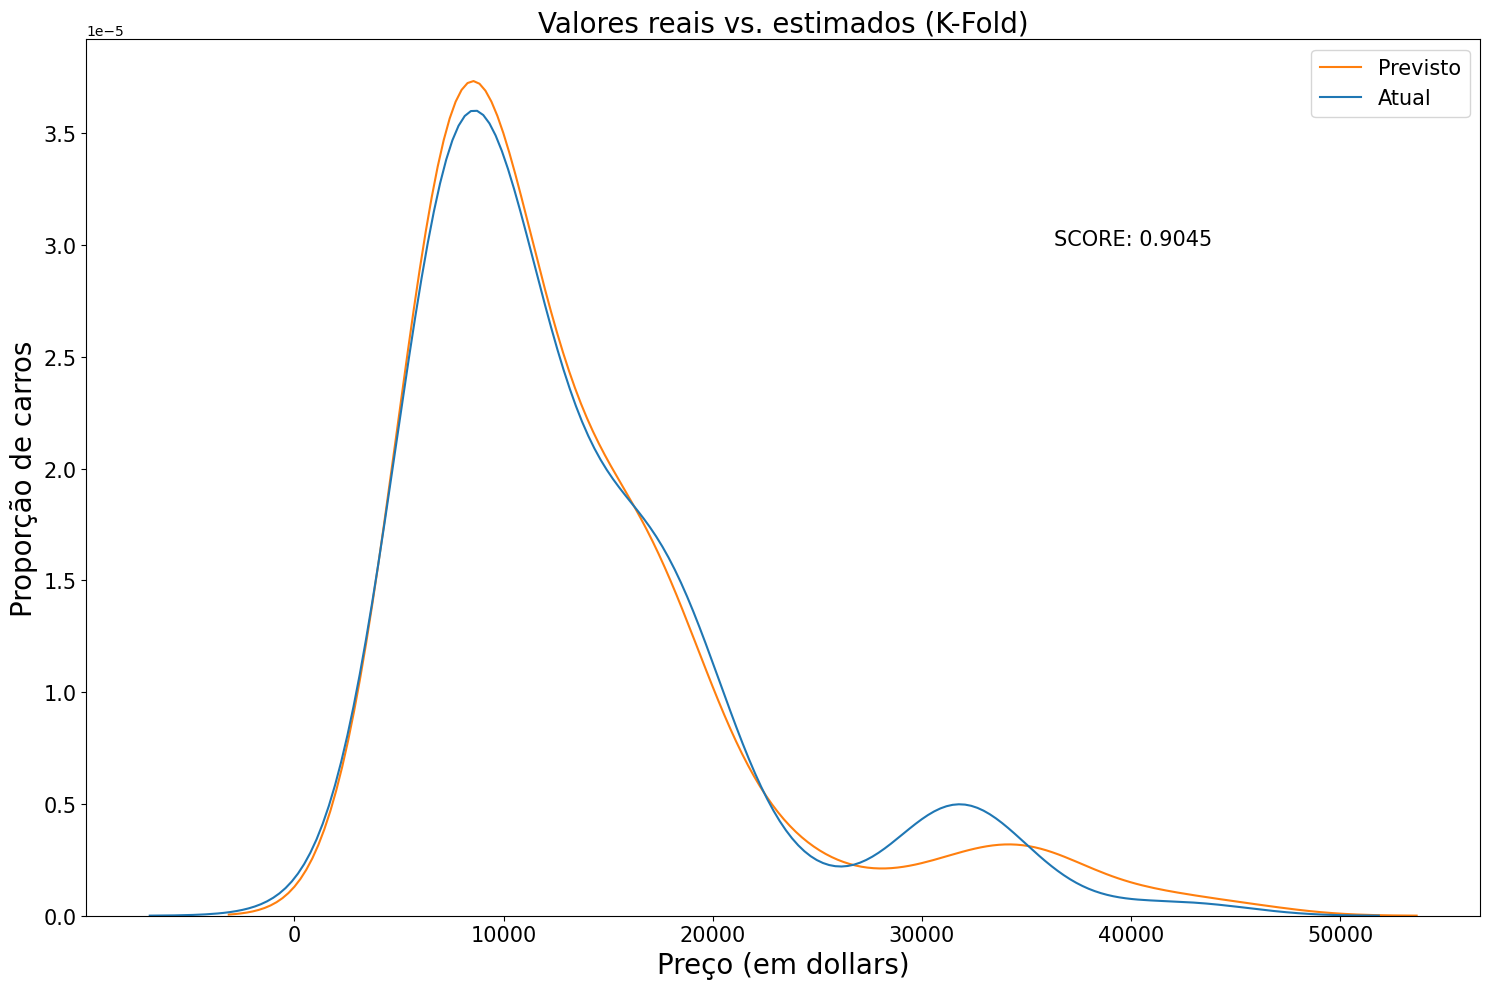

In [173]:
plt.figure(figsize=(15, 10))

sns.kdeplot(data=[y_pred_all, y_true_all])

plt.title('Valores reais vs. estimados (K-Fold)', size=20)
plt.xlabel('Preço (em dollars)', size=20)
plt.ylabel('Proporção de carros', size=20)
plt.xticks(size=15)
plt.yticks(size=15)
plt.legend(labels=["Previsto", "Atual"], fontsize=15, bbox_to_anchor=(1, 1))

# Calcula R² geral entre todos os valores dos folds
from sklearn.metrics import r2_score
R2 = r2_score(y_true_all, y_pred_all)

tt = "SCORE: %0.4f" % R2
plt.text(max(y_true_all) * 0.8, 0.00003, tt, size=15)

plt.tight_layout()
plt.show()

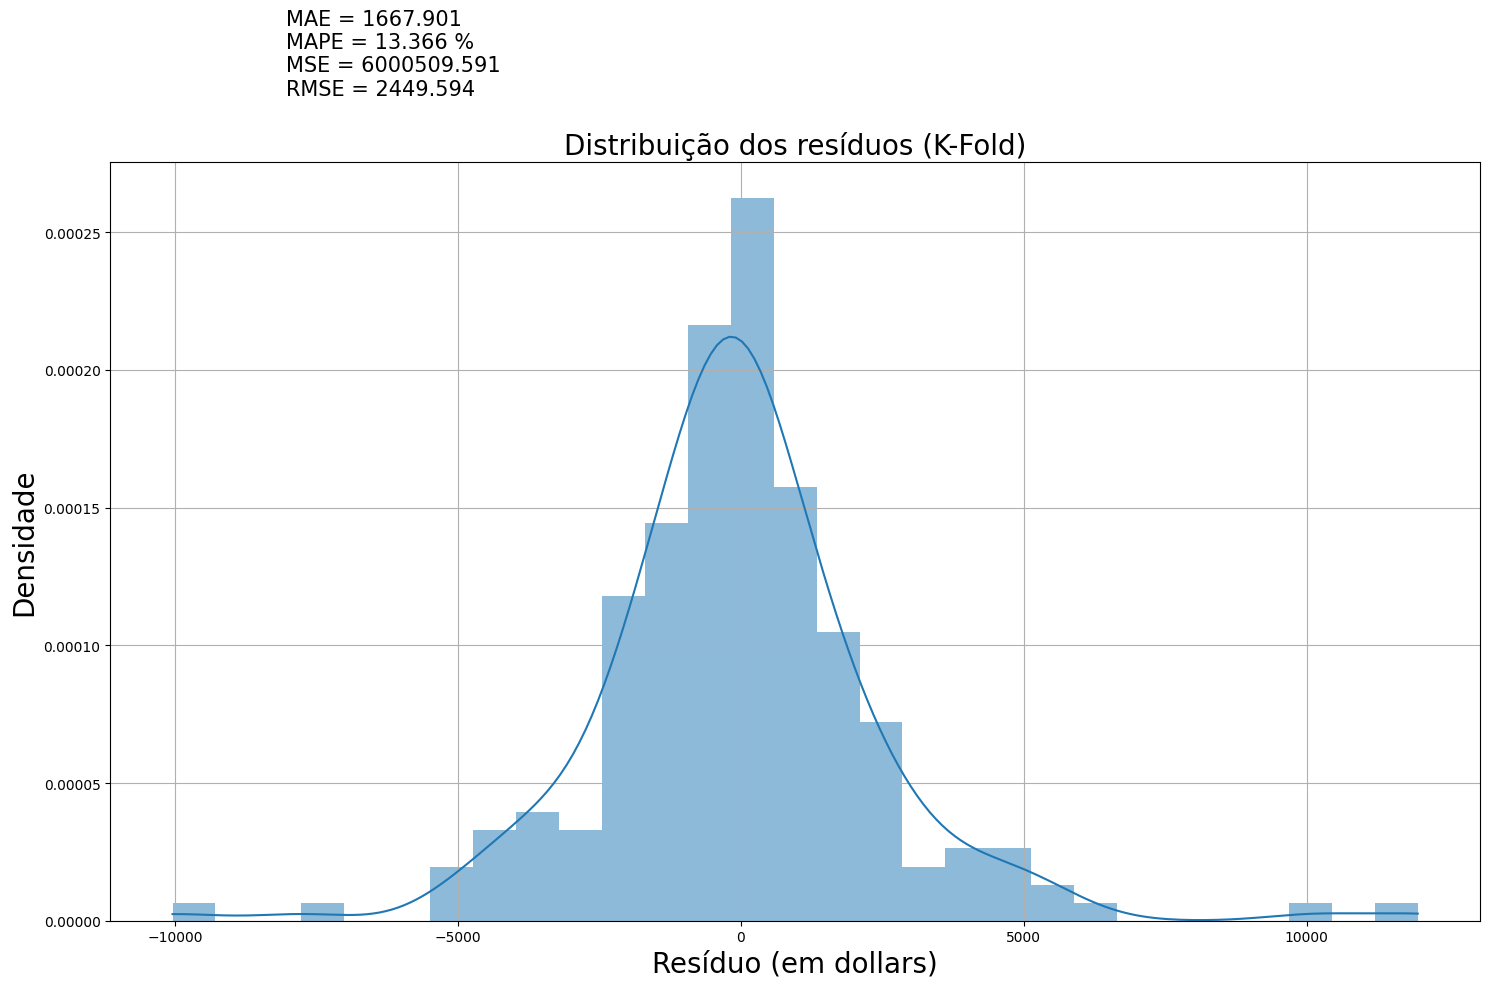

In [184]:
# Calcula resíduos
residuos = np.array(y_true_all) - np.array(y_pred_all)

# Calcula métricas com todos os dados dos folds
mae = mean_absolute_error(y_true_all, y_pred_all)
mape = 100 * mean_absolute_percentage_error(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)

# Texto com métricas
tt = "MAE = %.3f  \nMAPE = %.3f %%  \nMSE = %.3f  \nRMSE = %.3f" % (mae, mape, mse, rmse)

# Gráfico
plt.figure(figsize=(15, 10))
sns.histplot(x=residuos, kde=True, stat="density", linewidth=0)
plt.text(x=min(residuos)*0.8, y=0.0003, s=tt, size=15, color="black")
plt.xlabel('Resíduo (em dollars)', size=20)
plt.ylabel('Densidade', size=20)
plt.title("Distribuição dos resíduos (K-Fold)", size=20)
plt.grid(True)
plt.tight_layout()
plt.show()

In [175]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

# Carregando o modelo
lm.fit(X_train, y_train)

# Exibindo o R^2
R2_train=lm.score(X_train, y_train)
R2_test=lm.score(X_test, y_test)

print("SCORE Train: %.4f \nSCORE Test: %.4f" % (R2_train,R2_test))

SCORE Train: 0.9666 
SCORE Test: 0.8841


### Utilizando todas as variáveis

In [176]:
cat = ['object']
df_cat = df.select_dtypes(include=cat)
df_cat

,make,fuel-type,aspiration,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...
196,volvo,gas,std,sedan,rwd,front,ohc,four,mpfi
197,volvo,gas,turbo,sedan,rwd,front,ohc,four,mpfi
198,volvo,gas,std,sedan,rwd,front,ohcv,six,mpfi
199,volvo,diesel,turbo,sedan,rwd,front,ohc,six,idi


In [177]:
for col in df_cat.columns:
    print(col,df_cat[col].unique())

#mudar make
#'bmw', 'BMW'
#'dodge', 'doge'
#'volkswagen', 'VW'
#'volv1', 'volvo'

make ['alfa-romero' 'audi' 'BMW' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
fuel-type ['gas' 'diesel']
aspiration ['std' 'turbo']
body-style ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drive-wheels ['rwd' 'fwd' '4wd']
engine-location ['front' 'rear']
engine-type ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf']
num-of-cylinders ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
fuel-system ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [178]:
df_cat['make'] = df_cat['make'].replace({'bmw': 'BMW','doge':'dodge','volkswagen':'VW','volvo':'volv1'})

In [179]:
# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(df_cat)

# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out())

# Concatene o DataFrame dummy com os outros dados
df_dummy_politomica = pd.concat([df.drop(df.select_dtypes(include=cat).columns, axis=1), dummy_df], axis=1)

df_dummy_politomica.head()

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,engine-size,bore,...,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,1,88.6,168.8,64.1,48.8,2548,130,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,122,1,88.6,168.8,64.1,48.8,2548,130,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,164,1,94.5,171.2,65.5,52.4,2823,152,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164,0,99.8,176.6,66.2,54.3,2337,109,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164,0,99.4,176.6,66.4,54.3,2824,136,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [180]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

# Carregando o modelo
lm.fit(X, Y)

# Exibindo o R^2
R2=lm.score(X,Y)

print("SCORE: %.4f" % R2)

SCORE: 0.9673


Text(45000, 3.3e-05, 'SCORE: 0.967304')

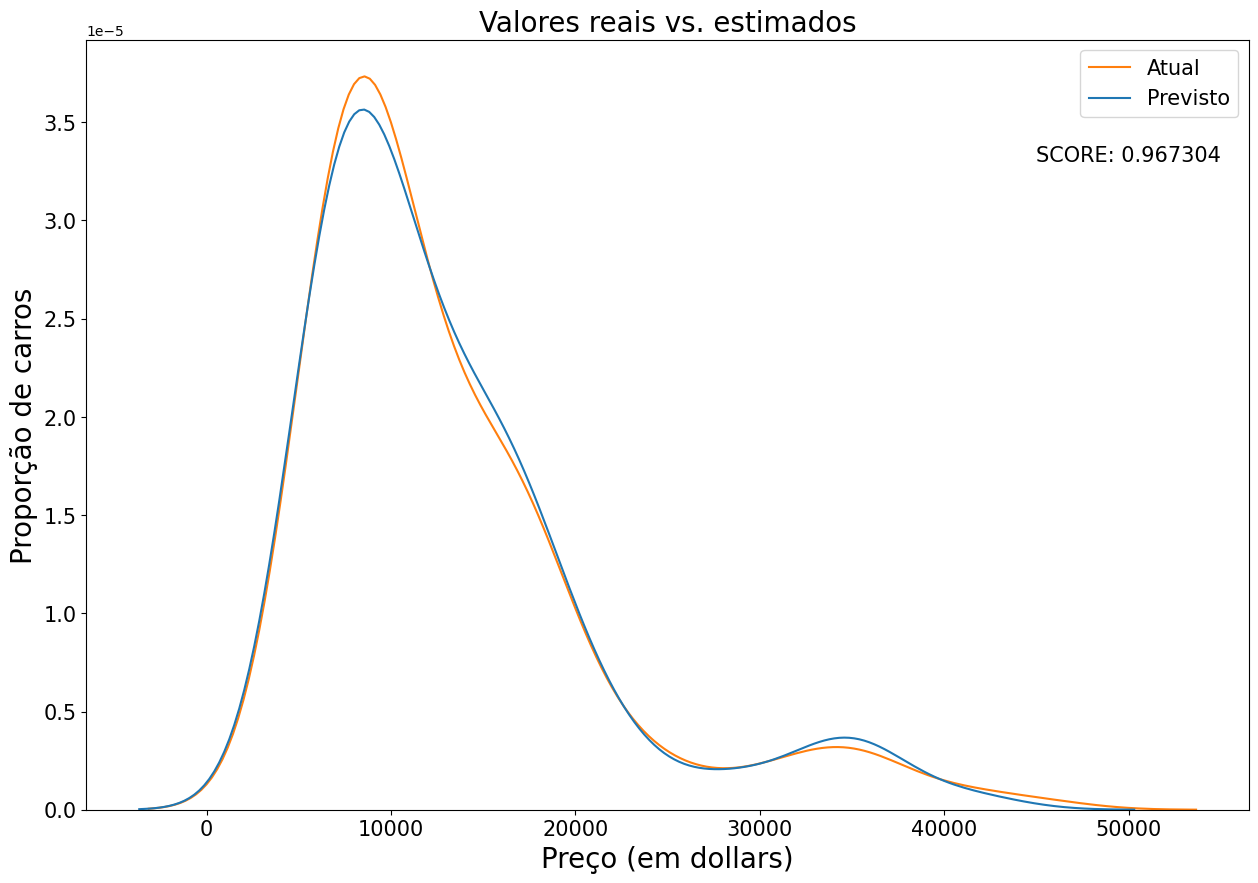

In [181]:
plt.figure(figsize=(15, 10))

sns.kdeplot(data = [lm.predict(X),df_dummy_politomica['price']])

plt.title('Valores reais vs. estimados', size = 20)
plt.xlabel('Preço (em dollars)', size = 20)
plt.ylabel('Proporção de carros', size = 20)
plt.yticks(size = 15)
plt.xticks(size = 15) 
plt.legend(labels=["Atual","Previsto"], fontsize = 15, bbox_to_anchor=(1, 1))

tt = "SCORE: %4f" % R2

plt.text(45000, 0.000033, tt, size = 15)

Text(0.5, 0, 'Resíduo (em dollars)')

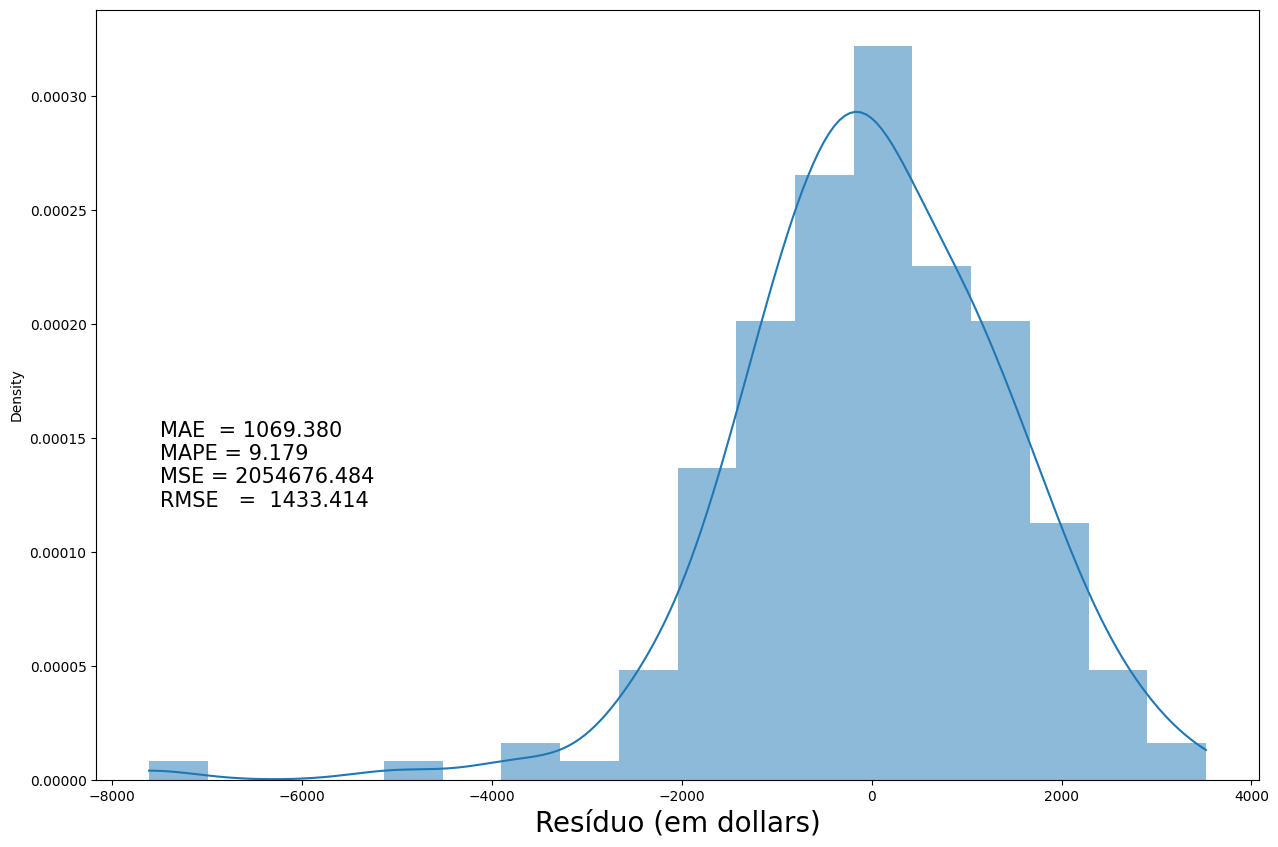

In [182]:
y_train = df_dummy_politomica['price']
y_pred  = lm.predict(X)

mae = mean_absolute_error(y_train, y_pred)
mape = 100*mean_absolute_percentage_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)

plt.figure(figsize=(15, 10))

tt = "MAE  = %.3f \nMAPE = %.3f \nMSE = %.3f \nRMSE   =  %.3f" % (mae, mape, mse, rmse)

sns.histplot(x=y_pred-df_dummy_politomica['price'], kde=True, stat="density", linewidth=0)
plt.text(-7500, 0.00012, tt, size=15, color = "black")
plt.xlabel('Resíduo (em dollars)', size = 20)

In [183]:
X = df_dummy_politomica[df_dummy_politomica.drop(labels='price',axis='columns').columns]
Y = df_dummy_politomica['price']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

# Carregando o modelo
lm.fit(X_train, y_train)

# Predizendo os valores
#df_dummy_politomica.loc[:,'YHat'] = lm.predict(X)

# Exibindo o R^2
R2_train=lm.score(X_train, y_train)
R2_test=lm.score(X_test, y_test)

print("SCORE Train: %.4f \nSCORE Test: %.4f" % (R2_train,R2_test))

SCORE Train: 0.9666 
SCORE Test: 0.8841


## Referências:

Translated and inspired in the material developed by IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>

Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>

Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>

Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Fique Conectado

- [![YouTube](https://img.icons8.com/ios-filled/40/000000/youtube-play.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/ios-filled/40/000000/linkedin.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/ios-filled/40/000000/instagram-new.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>, <a href="https://www.linkedin.com/in/hesauhugocavalcanti/" target="_blank">Hesau Hugo</a> , <a href="https://www.linkedin.com/in/joão-gabriel-santin-botelho/" target="_blank">João Gabriel</a>

## Referências:

Traduzido e inspirado do material desenvolviedo pela IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>
* Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>
* Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 04-04-2021       | 1.0     | Eduardo Pecora    | Inicial               |
| 03-11-2021       | 1.1     | Eduardo Pecora    | Estrutura Aula        |
| 08-03-2022       | 1.2     | Eduardo Pecora    | GitHub                |
| 17-04-2023       | 1.3     | Hesau Hugo        | Reestruturação        |
| 18-09-2024       | 1.4     | João Gabriel      | Atualização           |